<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Task3_Model_assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bank-loan.csv to bank-loan.csv


Accuracy: 0.8142857142857143
ROC-AUC: 0.8421052631578948

Confusion Matrix:
[[89 13]
 [13 25]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87       102
         1.0       0.66      0.66      0.66        38

    accuracy                           0.81       140
   macro avg       0.77      0.77      0.77       140
weighted avg       0.81      0.81      0.81       140



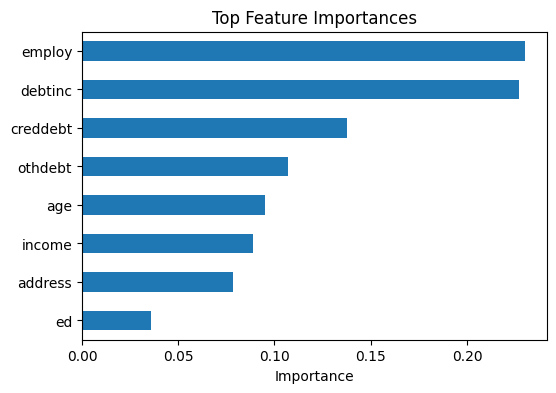

In [9]:
# =========================
# Task 3: Model Training & Evaluation
# =========================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# -------------------------
# 1. Load and Prepare Data
# -------------------------
df = pd.read_csv('bank-loan.csv')

# Remove missing target
df = df.dropna(subset=['default'])

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# -------------------------
# 2. Define Features & Target
# -------------------------
X = df.drop('default', axis=1)
y = df['default']

# -------------------------
# 3. Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 4. Train Model
# -------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------
# 5. Predictions
# -------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# -------------------------
# 6. Evaluation
# -------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -------------------------
# 7. Feature Importance (A+ part)
# -------------------------
importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot Top 10
feat_imp.head(10).plot(kind='barh', figsize=(6,4))
plt.title('Top Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()